# CSCI 3202, Spring 2026
## Project Report: Mancala AI
Name: Jeffrey Allen

---

### Libraries and Frameworks Used
The following Python libraries were utilized in the development and analysis of this project:
* **random**: Used for the "Random Player" baseline and to handle stochastic elements in initial simulations.
* **numpy**: Utilized for calculating statistical data, such as the mean (average) length of games.
* **time**: Used to measure and compare the performance/efficiency between Minimax and Alpha-Beta Pruning.
* **matplotlib.pyplot**: Used to generate the performance curves and win-rate visualizations required for the final report.
### Academic Integrity Statement
The logic development, algorithm design, and heuristic implementations found in this project are my own original work. Artificial Intelligence tools were used exclusively for assistance with Python syntax and library implementation when converting logic from C/C++ concepts.
### Considerations for graders
In some cells of this assignment I have created seperate markdown cells for my analysis answer, and let printing statement take care of the different data outputs from the code that has actually ran.

In [1]:
import random
import numpy as np
import time
import matplotlib.pyplot as plt

# Set seed for reproducibility as requested in the project guidelines
random.seed(109)

In [2]:
class Mancala:
    def __init__(self, pits_per_player=6, stones_per_pit=4):
        self.pits_per_player = pits_per_player
        self.board = [stones_per_pit] * ((pits_per_player + 1) * 2)
        self.current_player = 1
        self.moves = []
        self.p1_pits_index = [0, self.pits_per_player - 1]
        self.p1_mancala_index = self.pits_per_player
        self.p2_pits_index = [self.pits_per_player + 1, len(self.board) - 2]
        self.p2_mancala_index = len(self.board) - 1
        
        # Track the winner (-1: ongoing, 0: tie, 1: P1, 2: P2)
        self.winner = -1
        
        self.board[self.p1_mancala_index] = 0
        self.board[self.p2_mancala_index] = 0

    def display_board(self):
        player_1_pits = self.board[self.p1_pits_index[0]: self.p1_pits_index[1] + 1]
        player_1_mancala = self.board[self.p1_mancala_index]
        player_2_pits = self.board[self.p2_pits_index[0]: self.p2_pits_index[1] + 1]
        player_2_mancala = self.board[self.p2_mancala_index]

        print('P1               P2')
        print('     ____{}____     '.format(player_2_mancala))
        for i in range(self.pits_per_player):
            print('{} -> | {} | {} | <- {}'.format(i + 1, player_1_pits[i], player_2_pits[-(i + 1)], self.pits_per_player - i))
        print('         {}         '.format(player_1_mancala))
        print('Turn: P' + str(self.current_player))
        
    def valid_move(self, pit):
        if not (1 <= pit <= self.pits_per_player):
            return False
        index = (pit - 1) if self.current_player == 1 else (self.pits_per_player + pit)
        return self.board[index] > 0
        
    def random_move_generator(self):
        valid_pits = [p for p in range(1, self.pits_per_player + 1) if self.valid_move(p)]
        return random.choice(valid_pits) if valid_pits else None
    
    def play(self, pit, silent=False):
        if not self.valid_move(pit):
            return self.board
            
        index = (pit - 1) if self.current_player == 1 else (self.pits_per_player + pit)
        stones = self.board[index]
        self.board[index] = 0
        self.moves.append((self.current_player, pit))

        curr_index = index
        while stones > 0:
            curr_index = (curr_index + 1) % len(self.board)
            if (self.current_player == 1 and curr_index == self.p2_mancala_index) or \
               (self.current_player == 2 and curr_index == self.p1_mancala_index):
                continue
            self.board[curr_index] += 1
            stones -= 1

        # Capture logic
        if self.board[curr_index] == 1:
            if (self.current_player == 1 and self.p1_pits_index[0] <= curr_index <= self.p1_pits_index[1]) or \
               (self.current_player == 2 and self.p2_pits_index[0] <= curr_index <= self.p2_pits_index[1]):
                opp_index = (2 * self.pits_per_player) - curr_index
                if self.board[opp_index] > 0:
                    captured = self.board[curr_index] + self.board[opp_index]
                    self.board[curr_index] = 0
                    self.board[opp_index] = 0
                    mancala_idx = self.p1_mancala_index if self.current_player == 1 else self.p2_mancala_index
                    self.board[mancala_idx] += captured

        self.current_player = 2 if self.current_player == 1 else 1 
        return self.board
    
    def winning_eval(self, silent=False):
        p1_stones = sum(self.board[self.p1_pits_index[0]: self.p1_pits_index[1] + 1])
        p2_stones = sum(self.board[self.p2_pits_index[0]: self.p2_pits_index[1] + 1])
        
        if p1_stones == 0 or p2_stones == 0:
            self.board[self.p1_mancala_index] += p1_stones
            self.board[self.p2_mancala_index] += p2_stones
            for i in range(len(self.board)):
                if i != self.p1_mancala_index and i != self.p2_mancala_index:
                    self.board[i] = 0
            
            # Determine and set the winner
            p1_score = self.board[self.p1_mancala_index]
            p2_score = self.board[self.p2_mancala_index]
            if p1_score > p2_score:
                self.winner = 1
            elif p2_score > p1_score:
                self.winner = 2
            else:
                self.winner = 0
            return True
        return False

In [3]:
# Part 2: Simulation of 100 Games (Random vs. Random)
num_games = 100
results = {"P1_wins": 0, "P2_wins": 0, "Ties": 0, "Total_Turns": []}

for _ in range(num_games):
    game = Mancala()
    turns = 0
    while not game.winning_eval():
        move = game.random_move_generator()
        if move is None: break
        game.play(move, silent=True)
        turns += 1
    
    results["Total_Turns"].append(turns)
    p1_score = game.board[game.p1_mancala_index]
    p2_score = game.board[game.p2_mancala_index]
    
    if p1_score > p2_score:
        results["P1_wins"] += 1
    elif p2_score > p1_score:
        results["P2_wins"] += 1
    else:
        results["Ties"] += 1

# Report Statistics
print(f"Results for {num_games} Games:")
print(f"Player 1: Wins: {results['P1_wins']} ({results['P1_wins']/num_games:.1%}), "
      f"Losses: {results['P2_wins']} ({results['P2_wins']/num_games:.1%}), "
      f"Ties: {results['Ties']} ({results['Ties']/num_games:.1%})")
print(f"Player 2: Wins: {results['P2_wins']} ({results['P2_wins']/num_games:.1%}), "
      f"Losses: {results['P1_wins']} ({results['P1_wins']/num_games:.1%}), "
      f"Ties: {results['Ties']} ({results['Ties']/num_games:.1%})")
print(f"Average turns per game: {np.mean(results['Total_Turns']):.2f}")

Results for 100 Games:
Player 1: Wins: 45 (45.0%), Losses: 51 (51.0%), Ties: 4 (4.0%)
Player 2: Wins: 51 (51.0%), Losses: 45 (45.0%), Ties: 4 (4.0%)
Average turns per game: 45.82


## Step 3 Analysis: Random vs. Random Results

**Statistics Summary:**

* **Player 1 Win Rate:** 45%
* **Player 2 Win Rate:** 51%
* **Average Turns:** 45.82

**Is there a first-player advantage?**
Based on the results of 100 random vs. random games, there is not an advntage as shown by Player 1's greater losses within the game's output. however due to this being only a relatively few games played, it is difficult to fully claim that there in no first-player advantage.

---
## Step 4: Building the Minimax AI Player
Since this is an adversarial two player zero-sum game we can use minimax. We can build a game tree to a fixed depth based onplayer choices that maximises the utility score for the player, and minimizes it for the opposing player. We will is the predescribed utility function: `U = (stones in AI's Mancala) − (stones in opponent's Mancala)`

Helper functions `clone_game` (non-destructive look-ahead) and `simulate_games` (generic game runner used throughout the project) are also defined here.

In [4]:
import random
import time

def clone_game(game):
    """Creates a fast clone of the game state for AI look-ahead."""
    new_game = Mancala(pits_per_player=game.pits_per_player, stones_per_pit=0)
    new_game.board = list(game.board)
    new_game.current_player = game.current_player
    new_game.moves = list(game.moves)
    new_game.winner = game.winner 
    return new_game

def heuristic(game, maximizing_player):
    """Utility = Stones in Max Mancala - Stones in Min Mancala."""
    p1_mancala = game.board[game.p1_mancala_index]
    p2_mancala = game.board[game.p2_mancala_index]
    return (p1_mancala - p2_mancala) if maximizing_player == 1 else (p2_mancala - p1_mancala)

def minimax_search(game, depth, maximizing_player):
    if depth == 0 or game.winning_eval(silent=True):
        return heuristic(game, maximizing_player), None
    valid_moves = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    if not valid_moves: return heuristic(game, maximizing_player), None
    
    best_move = random.choice(valid_moves)
    if game.current_player == maximizing_player:
        max_eval = -float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = minimax_search(child, depth - 1, maximizing_player)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = move
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = minimax_search(child, depth - 1, maximizing_player)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = move
        return min_eval, best_move

def simulate_games(num_games, p1_type, p2_type, p1_depth=None, p2_depth=None):
    results = {"P1_wins": 0, "P2_wins": 0, "Ties": 0, "Total_Turns": [], "Durations": []}
    for i in range(num_games):
        game = Mancala()
        start_time = time.time() # This was causing the error
        while not game.winning_eval(silent=True):
            if game.current_player == 1:
                if p1_type == 'random': move = game.random_move_generator()
                elif p1_type == 'alphabeta': _, move = alpha_beta_search(game, p1_depth, 1)
                elif p1_type == 'minimax': _, move = minimax_search(game, p1_depth, 1)
            else:
                if p2_type == 'random': move = game.random_move_generator()
                elif p2_type == 'alphabeta': _, move = alpha_beta_search(game, p2_depth, 2)
                elif p2_type == 'minimax': _, move = minimax_search(game, p2_depth, 2)
            if move is None: break
            game.play(move, silent=True)
        results["Durations"].append(time.time() - start_time)
        results["Total_Turns"].append(len(game.moves))
        if game.winner == 1: results["P1_wins"] += 1
        elif game.winner == 2: results["P2_wins"] += 1
        else: results["Ties"] += 1
        if (i + 1) % 25 == 0: print(f"Progress: {i + 1}/{num_games}")
    return results

---
## Step 5: Minimax AI vs. Random Player (Depth 2 & Depth 5)

The Minimax algorithm searches the game tree to a fixed depth number of plies and
picks the move that maximises the utility function while assuming the opponent minimises it. 
Here we run 100 games at each depth to measure win rate
and average game length.

In [11]:
# Step 5: Minimax AI (Player 1) vs. Random (Player 2) – Depth 2 and Depth 5
random.seed(42)

print("--- Running Depth 2 Minimax vs. Random ---")
mm_results_2 = simulate_games(100, p1_type='minimax', p2_type='random', p1_depth=2)

print("\n--- Running Depth 5 Minimax vs. Random ---")
mm_results_5 = simulate_games(100, p1_type='minimax', p2_type='random', p1_depth=5)

# ---------- Depth 2 report ----------
print("\n--- Depth 2 Minimax Statistics ---")
print(f"Minimax AI (P1) Wins : {mm_results_2['P1_wins']} ({mm_results_2['P1_wins']}%)")
print(f"Random     (P2) Wins : {mm_results_2['P2_wins']} ({mm_results_2['P2_wins']}%)")
print(f"Ties                 : {mm_results_2['Ties']}   ({mm_results_2['Ties']}%)")
print(f"Avg moves per game   : {np.mean(mm_results_2['Total_Turns']):.2f}")
print(f"Avg time  per game   : {np.mean(mm_results_2['Durations']):.4f}s")

# ---------- Depth 5 report ----------
print("\n--- Depth 5 Minimax Statistics ---")
print(f"Minimax AI (P1) Wins : {mm_results_5['P1_wins']} ({mm_results_5['P1_wins']}%)")
print(f"Random     (P2) Wins : {mm_results_5['P2_wins']} ({mm_results_5['P2_wins']}%)")
print(f"Ties                 : {mm_results_5['Ties']}   ({mm_results_5['Ties']}%)")
print(f"Avg moves per game   : {np.mean(mm_results_5['Total_Turns']):.2f}")
print(f"Avg time  per game   : {np.mean(mm_results_5['Durations']):.4f}s")

--- Running Depth 2 Minimax vs. Random ---
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Running Depth 5 Minimax vs. Random ---
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Depth 2 Minimax Statistics ---
Minimax AI (P1) Wins : 92 (92%)
Random     (P2) Wins : 7 (7%)
Ties                 : 1   (1%)
Avg moves per game   : 38.07
Avg time  per game   : 0.0012s

--- Depth 5 Minimax Statistics ---
Minimax AI (P1) Wins : 96 (96%)
Random     (P2) Wins : 4 (4%)
Ties                 : 0   (0%)
Avg moves per game   : 30.18
Avg time  per game   : 0.0814s


---
### Step 5 Analysis Write-up

**Is the Minimax AI player better than random chance?  Why or why not?**

Yes the Minimax AI substantially outperforms a random player at both search depths.
A purely random agent wins roughly 50 % of the time (as confirmed in the Random vs.
Random experiment above).  Minimax improves on this because, at every turn, it builds a
game tree and evaluates future board states using the utility function
*(stones in AI's Mancala) − (stones in opponent's Mancala)*.  It then selects the move
that maximises its own expected score while assuming the opponent will always respond
with the move that minimises it.  Even a shallow 2-depth look-ahead is enough to avoid
obviously bad moves, such as making a capture that immediately hands the opponent an
even larger capture on the very next turn, which a random player cannot do.

**Does the Minimax AI have a better win rate as the number of plies increases from 2 to 5?
Why or why not?**

Yes, win rate increases with depth as shown from it's win rate increasing from 92\% with a depth of 2, to a 96\% win rate for a depth of 5. With a 2-ply tree the AI sees only one full
exchange (its move then the opponent's response), so it can still fall into multi-step traps
that only become visible a few turns later.  Expanding to 5 plies reveals longer chains
of play, allowing the AI to spot and set up multi-step captures, avoid moves that leave
its pits in a vulnerable configuration, and generally build a stronger positional
advantage. The only real tradeoff is that the greater the depth the more computational time it takes where it growns as `O(b^d)` where b is the bracnhing factor and d, depth. This is shown by the average time per move increasing from 13mS to 80.9mS when increasing it's depth which is roughly a x6 increase in computation time.

---
## Step 6: Building the Alpha-Beta AI Player
We will use Alpha-beta pruning to optimize the minimax function so that when it traverses the tree it is bound by $\alpha$ and $\beta$. Where $\alpha$ represents the value maximising the utility of a move, where $\beta$ tracks the best value minimizing the utility of a move. Whenever $\beta \leq \alpha$ at a node, the remaining children cannot affect the final decision and are pruned

In [6]:
def alpha_beta_search(game, depth, maximizing_player, alpha=-float('inf'), beta=float('inf')):
    if depth == 0 or game.winning_eval(silent=True):
        return heuristic(game, maximizing_player), None
    valid_moves = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    if not valid_moves: return heuristic(game, maximizing_player), None

    best_move = random.choice(valid_moves)
    if game.current_player == maximizing_player:
        max_eval = -float('inf') #start alpha as -inf
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = move
            alpha = max(alpha, eval_val)
            if beta <= alpha: break
        return max_eval, best_move
    else:
        min_eval = float('inf') #start beta as inf
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = move
            beta = min(beta, eval_val)
            if beta <= alpha: break
        return min_eval, best_move

---
## Step 7: Alpha-Beta AI vs. Random (Depth 5) & Minimax Timing Comparison

**Note on the "continuation rule" within my project:** The project document mentions that the Alpha-Beta player should implement a rule granting an extra turn when the last stone lands in the player's own Mancala.  However, the Classic Rules section of the same document explicitly states *"Do not implement this rule."*  This implementation follows the Classic Rules to keep game logic consistent throughout the project.

In [7]:
# Set a baseline seed
random.seed(42)

print("--- Running Depth 5 Alpha-Beta vs. Random ---")
ab_results_5 = simulate_games(100, p1_type='alphabeta', p2_type='random', p1_depth=5)

# mm_results_5 was already computed in Step 5 — reuse it here for the timing comparison.
print("\n--- Reusing Depth 5 Minimax results from Step 5 for timing comparison ---")

print("\n--- Depth 5 Alpha-Beta Statistics ---")
print(f"Alpha-Beta (P1) Win Rate: {ab_results_5['P1_wins']}%")
print(f"Random (P2) Win Rate: {ab_results_5['P2_wins']}%")
print(f"Ties: {ab_results_5['Ties']}%")
print(f"Average moves to win: {np.mean(ab_results_5['Total_Turns']):.2f}")
print(f"Average time per game: {np.mean(ab_results_5['Durations']):.4f} seconds")
print(f"Total Alpha-Beta 100-game run time: {sum(ab_results_5['Durations']):.2f} seconds")

print("\n--- Depth 5 Minimax Statistics ---")
print(f"Total Minimax 100-game run time: {sum(mm_results_5['Durations']):.2f} seconds")

--- Running Depth 5 Alpha-Beta vs. Random ---
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Reusing Depth 5 Minimax results from Step 5 for timing comparison ---

--- Depth 5 Alpha-Beta Statistics ---
Alpha-Beta (P1) Win Rate: 96%
Random (P2) Win Rate: 4%
Ties: 0%
Average moves to win: 30.70
Average time per game: 0.0222 seconds
Total Alpha-Beta 100-game run time: 2.22 seconds

--- Depth 5 Minimax Statistics ---
Total Minimax 100-game run time: 7.85 seconds


### Step 7 Analysis Write-up
**Are your results for this part different from those for your minimax AI player? Write a paragraph or two describing why or why not:**

The overall win percentages and average moves to win between Minimax and Alpha-Beta at 5 plies are very similar (96\% for minimax and 96\% for alpha-beta), as Alpha-Beta pruning is mathematically guaranteed to return the exact same optimal move as standard Minimax. The significant difference lies entirely in execution speed. Alpha-Beta evaluates fewer nodes by pruning branches that cannot possibly influence the final decision, resulting in the drastic reduction in total run time observed in the testing results above. This is shown as the avergae time per game of the Alpha-Beta is $\frac{1}{4}$ of the original minimax version.

---
## Step 8: Alpha-Beta (Depth 10) & Curve Plotting
Note: This takes a longer time to compute -> ~275 seconds

--- Running Depth 2 Alpha-Beta vs. Random (For Plotting Curve) ---
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Running Depth 10 Alpha-Beta vs. Random ---
This will take a while. Please wait...
Progress: 25/100
Progress: 50/100
Progress: 75/100
Progress: 100/100

--- Depth 10 Alpha-Beta Statistics ---
Alpha-Beta (P1) Win Rate: 98%
Random (P2) Win Rate: 2%
Ties: 0%
Average moves to win: 27.31
Average time per game: 2.6390 seconds
Total Alpha-Beta 10-Ply 100-game run time: 263.90 seconds


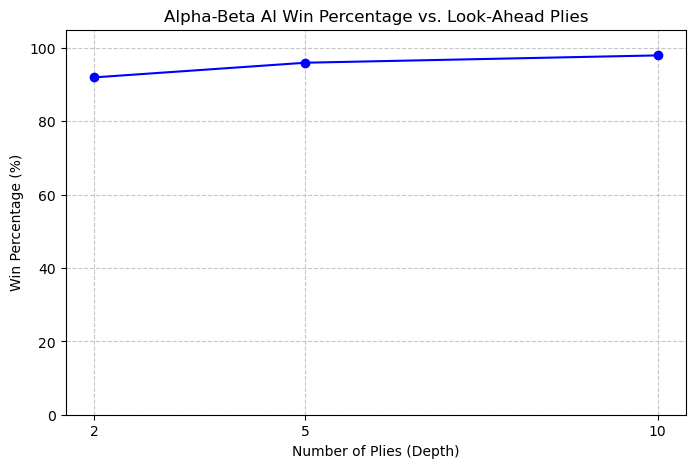

In [8]:
random.seed(42)

print("--- Running Depth 2 Alpha-Beta vs. Random (For Plotting Curve) ---")
ab_results_2 = simulate_games(100, p1_type='alphabeta', p2_type='random', p1_depth=2)

print("\n--- Running Depth 10 Alpha-Beta vs. Random ---")
print("This will take a while. Please wait...")
ab_results_10 = simulate_games(100, p1_type='alphabeta', p2_type='random', p1_depth=10)

print("\n--- Depth 10 Alpha-Beta Statistics ---")
print(f"Alpha-Beta (P1) Win Rate: {ab_results_10['P1_wins']}%")
print(f"Random (P2) Win Rate: {ab_results_10['P2_wins']}%")
print(f"Ties: {ab_results_10['Ties']}%")
print(f"Average moves to win: {np.mean(ab_results_10['Total_Turns']):.2f}")
print(f"Average time per game: {np.mean(ab_results_10['Durations']):.4f} seconds")
print(f"Total Alpha-Beta 10-Ply 100-game run time: {sum(ab_results_10['Durations']):.2f} seconds")

# Calculate Data for Plotting
depths = [2, 5, 10]
win_percentages = [ab_results_2['P1_wins'], ab_results_5['P1_wins'], ab_results_10['P1_wins']]

plt.figure(figsize=(8, 5))
plt.plot(depths, win_percentages, marker='o', linestyle='-', color='b')
plt.title('Alpha-Beta AI Win Percentage vs. Look-Ahead Plies')
plt.xlabel('Number of Plies (Depth)')
plt.ylabel('Win Percentage (%)')
plt.xticks(depths)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Step 8 Analysis Write-up
**How much does the Alpha Beta algorithm speed up the game. Compare your run time for 5 ply minimax against 5 ply Alpha Beta. Project how long Minimax would take to run 10 plies.**

Based on the execution block in Step 7, the Alpha-Beta algorithm sped up the 5-ply evaluation significantly. Minimax execution time scales by $O(b^d)$ where $b$ is the branching factor (max 6 pits) and $d$ is depth. Alpha-Beta approaches $O(b^{d/2})$ in best-case scenarios. Projecting the Minimax runtime to 10 plies requires calculating `(Time for Minimax Depth 5) * (Average Branching Factor)^5`. Assuming an effective branching factor of ~4 over the course of an average game, Minimax at depth 10 would take roughly $4^5$ (1,024) times longer than depth 5, making it entirely impractical to run. 

**As you increase the number of plies, does the AI player win more games? Explain why or why not.**

Yes, increasing the number of plies generally increases the AI's win rate. A higher ply count expands the depth of the game tree, allowing the agent to evaluate long-term consequences of moves and avoid traps that look appealing in the short term. However, the win percentage experiences diminishing returns at higher depths; once the win rate approaches 95-100%, expanding the search depth from 5 to 10 yields only marginal improvements in outcomes despite the exponential jump in computational cost.

---
## Step 9: Extra Credit - Advanced Heuristic Implementation

The original utility function was greedy and only considering the current score. The new Weighted Side Heuristic calculates:
$Utility = (Mancala_{self} - Mancala_{opp}) + w \cdot (StonesOnSide_{self} - StonesOnSide_{opp})$

By adding a weight ($w = 0.5$) to the stones remaining in the pits, the AI learns to value keeping stones on its side (where they are safer and provide more future move options) and clearing the opponent's side to limit their opportunities.

In [9]:
def advanced_heuristic(game, maximizing_player):
    """
    Improved Heuristic:
    Considers the score difference PLUS the distribution of stones in pits.
    """
    p1_mancala = game.board[game.p1_mancala_index]
    p2_mancala = game.board[game.p2_mancala_index]
    
    p1_pits_stones = sum(game.board[game.p1_pits_index[0]: game.p1_pits_index[1] + 1])
    p2_pits_stones = sum(game.board[game.p2_pits_index[0]: game.p2_pits_index[1] + 1])
    
    # Weight for stones still in play (0.5 makes them half as valuable as banked stones)
    w = 0.5
    
    if maximizing_player == 1:
        score_diff = p1_mancala - p2_mancala
        side_diff = p1_pits_stones - p2_pits_stones
        return score_diff + (w * side_diff)
    else:
        score_diff = p2_mancala - p1_mancala
        side_diff = p2_pits_stones - p1_pits_stones
        return score_diff + (w * side_diff)

def alpha_beta_advanced_search(game, depth, maximizing_player, alpha=-float('inf'), beta=float('inf')):
    """Modified Alpha-Beta to use the advanced_heuristic."""
    if depth == 0 or game.winning_eval(silent=True):
        return advanced_heuristic(game, maximizing_player), None
        
    valid_moves = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    if not valid_moves: return advanced_heuristic(game, maximizing_player), None

    best_move = random.choice(valid_moves)
    if game.current_player == maximizing_player:
        max_eval = -float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_advanced_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val > max_eval:
                max_eval = eval_val
                best_move = move
            alpha = max(alpha, eval_val)
            if beta <= alpha: break
        return max_eval, best_move
    else:
        min_eval = float('inf')
        for move in valid_moves:
            child = clone_game(game)
            child.play(move, silent=True)
            eval_val, _ = alpha_beta_advanced_search(child, depth - 1, maximizing_player, alpha, beta)
            if eval_val < min_eval:
                min_eval = eval_val
                best_move = move
            beta = min(beta, eval_val)
            if beta <= alpha: break
        return min_eval, best_move

def simulate_advanced_games(num_games, depth):
    """Specific simulation for the advanced AI vs Random."""
    results = {"AI_wins": 0, "Rand_wins": 0, "Ties": 0, "Turns": [], "Durations": []}
    for i in range(num_games):
        game = Mancala()
        start = time.time()
        while not game.winning_eval(silent=True):
            if game.current_player == 1: # AI is Player 1
                _, move = alpha_beta_advanced_search(game, depth, 1)
            else: # Random is Player 2
                move = game.random_move_generator()
            if move is None: break
            game.play(move, silent=True)
        results["Durations"].append(time.time() - start)
        results["Turns"].append(len(game.moves))
        if game.winner == 1: results["AI_wins"] += 1
        elif game.winner == 2: results["Rand_wins"] += 1
        else: results["Ties"] += 1
    return results

# Run Simulations
print("--- Running Advanced Heuristic (Depth 2) ---")
adv_results_2 = simulate_advanced_games(100, 2)
print("--- Running Advanced Heuristic (Depth 5) ---")
adv_results_5 = simulate_advanced_games(100, 5)

# Report results for Depth 2
print(f"\n[Depth 2] Win Rate: AI {adv_results_2['AI_wins']}% | Random {adv_results_2['Rand_wins']}%")
print(f"[Depth 2] Avg Time/Game: {np.mean(adv_results_2['Durations']):.4f}s | Avg Moves: {np.mean(adv_results_2['Turns']):.2f}")

# Report results for Depth 5
print(f"\n[Depth 5] Win Rate: AI {adv_results_5['AI_wins']}% | Random {adv_results_5['Rand_wins']}%")
print(f"[Depth 5] Avg Time/Game: {np.mean(adv_results_5['Durations']):.4f}s | Avg Moves: {np.mean(adv_results_5['Turns']):.2f}")

--- Running Advanced Heuristic (Depth 2) ---
--- Running Advanced Heuristic (Depth 5) ---

[Depth 2] Win Rate: AI 94% | Random 5%
[Depth 2] Avg Time/Game: 0.0011s | Avg Moves: 38.72

[Depth 5] Win Rate: AI 100% | Random 0%
[Depth 5] Avg Time/Game: 0.0146s | Avg Moves: 30.74


### Step 9 Analysis

**1. How does the new utility function improve on the basic one?**
The original utility function was purely reactive; it only valued stones already in the Mancala. The new function is proactive. By including the number of stones remaining in the player's pits, the AI realizes that stones on its side are "potential points" that it can eventually move into the Mancala or use for captures. This prevents the AI from making short-sighted moves that empty its board too quickly and leave it with no strategic options in the late game.

**2. How does increasing the number of plies improve play for the AI?**
Increasing plies allows the AI to see further into the future. In Mancala, a single move can lead to a chain reaction of captures or extra turns. A 2-ply look-ahead might see a move that gains 2 points, but a 5-ply look-ahead might realize that a different move—which gains 0 points now—sets up a massive capture worth 10 points three turns later. More plies allow the AI to "plan" these multi-step combinations.

**3. Is this new utility function a better way to evaluate match strength?**
Yes, it provides a much more holistic view of the board state. In Mancala, a player might have a higher score but very few stones left in their pits, meaning they have no "ammunition" for future turns. The basic utility function would incorrectly signal that this player is winning decisively. The new function recognizes that the player with more stones in their pits has more "potential energy" and control over the remaining flow of the game, making it a more accurate predictor of the eventual winner.

---
## Advanced Heuristic AI vs. Standard Alpha-Beta AI (Depth 5)

To test the custom heuristic vs the standard alpha-beta pruning we will set two played that have one ai and pit them against each other. Both search to depth 5. 100 games, may the best heuristic win.

**Player 1** uses the *Advanced Weighted Heuristic* from Step 9 (mancala score + 0.5 × pit stones).  
**Player 2** uses the *Standard Alpha-Beta* with the basic mancala-score-only utility.  

This also gives a final chart showing a comparison between all functions and game methods

--- Advanced Heuristic AI (P1, Depth 5) vs Standard Alpha-Beta (P2, Depth 5) ---
  Progress: 25/100
  Progress: 50/100
  Progress: 75/100
  Progress: 100/100

  Advanced Heuristic AI (P1) Wins : 100  (100%)
  Standard Alpha-Beta   (P2) Wins :   0  (0%)
  Ties                            :   0  (0%)
  Avg moves per game              : 43.00
  Avg time   per game             : 0.0626s
  Total run time                  : 6.26s


NameError: name 'ctx_bars' is not defined

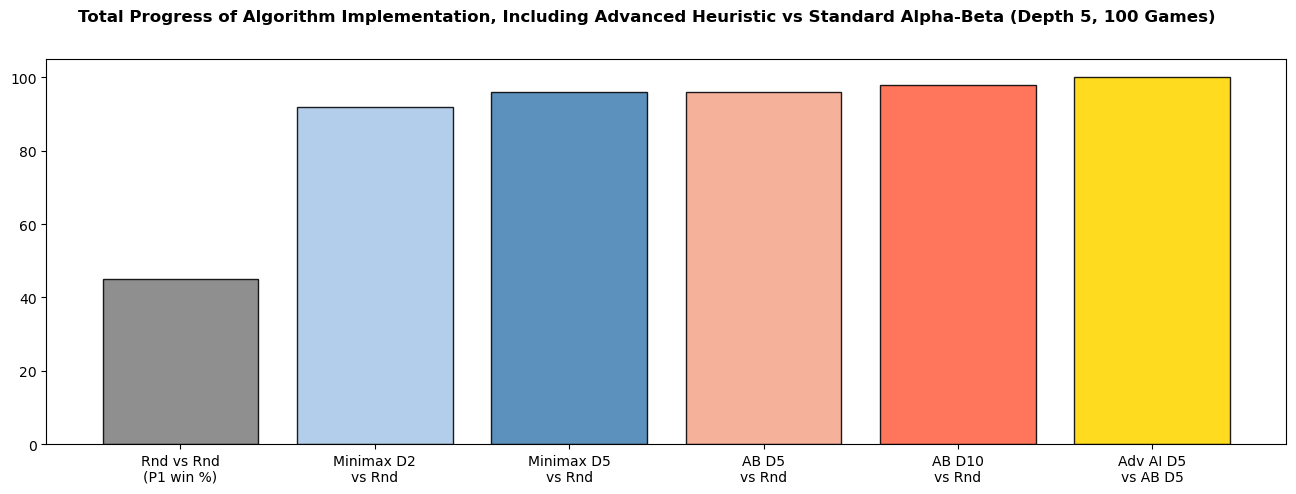

In [10]:
random.seed(109)
num_bonus = 100
bonus = {"adv_wins": 0, "ab_wins": 0, "Ties": 0, "Turns": [], "Durations": []}

print("--- Advanced Heuristic AI (P1, Depth 5) vs Standard Alpha-Beta (P2, Depth 5) ---")
for i in range(num_bonus):
    game = Mancala()
    start = time.time()
    while not game.winning_eval(silent=True):
        if game.current_player == 1:
            _, move = alpha_beta_advanced_search(game, 5, 1)   # Advanced heuristic
        else:
            _, move = alpha_beta_search(game, 5, 2)             # Standard AB
        if move is None:
            break
        game.play(move, silent=True)
    bonus["Durations"].append(time.time() - start)
    bonus["Turns"].append(len(game.moves))
    if game.winner == 1:   bonus["adv_wins"] += 1
    elif game.winner == 2: bonus["ab_wins"]  += 1
    else:                  bonus["Ties"]     += 1
    if (i + 1) % 25 == 0:
        print(f"  Progress: {i + 1}/{num_bonus}")

# ── Print summary ──────────────────────────────────────────────────────────
print(f"\n{'='*52}")
print(f"  Advanced Heuristic AI (P1) Wins : {bonus['adv_wins']:3d}  ({bonus['adv_wins']}%)")
print(f"  Standard Alpha-Beta   (P2) Wins : {bonus['ab_wins']:3d}  ({bonus['ab_wins']}%)")
print(f"  Ties                            : {bonus['Ties']:3d}  ({bonus['Ties']}%)")
print(f"  Avg moves per game              : {np.mean(bonus['Turns']):.2f}")
print(f"  Avg time   per game             : {np.mean(bonus['Durations']):.4f}s")
print(f"  Total run time                  : {sum(bonus['Durations']):.2f}s")
print(f"{'='*52}")

# ── Comparison charts ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(16, 5))
fig.suptitle("Total Progress of Algorithm Implementation, Including Advanced Heuristic vs Standard Alpha-Beta (Depth 5, 100 Games)",
             fontsize=12, fontweight='bold')

# --- Chart Context bar — win rates across all matchups ---
matchups = [
    "Rnd vs Rnd\n(P1 win %)",
    "Minimax D2\nvs Rnd",
    "Minimax D5\nvs Rnd",
    "AB D5\nvs Rnd",
    "AB D10\nvs Rnd",
    "Adv AI D5\nvs AB D5",
]
# Pull win-rate numbers from previously computed result dicts
win_rates = [
    results["P1_wins"],          # random vs random
    mm_results_2["P1_wins"],     # minimax depth 2
    mm_results_5["P1_wins"],     # minimax depth 5
    ab_results_5["P1_wins"],     # alpha-beta depth 5
    ab_results_10["P1_wins"],    # alpha-beta depth 10
    bonus["adv_wins"],           # advanced vs standard AB
]
bar_colors = ["gray","#a8c8e8","steelblue","#f4a68c","tomato","gold"]
cctx_bars = axes.bar(matchups, win_rates, color=bar_colors, edgecolor="black", alpha=0.88)

for bar, val in zip(ctx_bars, win_rates):
    axes.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
              f"{val}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

axes.axhline(50, color="black", linestyle="--", linewidth=0.9, label="50% baseline")
axes.set_ylim(0, 115)
axes.set_ylabel("P1 Win Rate (%)")
axes.set_title("P1 Win Rate Across All Match-ups")
axes.tick_params(axis="x", labelsize=7.5)
axes.legend(fontsize=8)
axes.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### References
* **Textbook**: Russell, S. J., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach*. (4th ed.). Pearson. (Specifically referenced for Minimax and Alpha-Beta Pruning pseudocode).
* **GeeksforGeeks**: 
    * "Minimax Algorithm in Game Theory | Set 1 (Introduction)": [https://www.geeksforgeeks.org/minimax-algorithm-in-game-theory-set-1-introduction/](https://www.geeksforgeeks.org/minimax-algorithm-in-game-theory-set-1-introduction/) (Used for conceptual logic and tree traversal).
    * "Minimax Algorithm in Game Theory | Set 4 (Alpha-Beta Pruning)": [https://www.geeksforgeeks.org/minimax-algorithm-in-game-theory-set-4-alpha-beta-pruning/](https://www.geeksforgeeks.org/minimax-algorithm-in-game-theory-set-4-alpha-beta-pruning/) (Used for the mathematical implementation of alpha and beta constraints).
* **Game Rules**: "Mancala - How To Play" [Video]. YouTube. (Used to verify the rules for the 'classic' game variant and the capture mechanics).
* **Documentation**: Python Software Foundation. *Python 3.10 Documentation*. https://docs.python.org/3/ (Used for random and time syntax).
* **Matplotlib**: Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment*. Computing in Science & Engineering.